Setup

In [140]:
import zipfile
import os

# Path to your uploaded zip file (replace with your filename)
zip_path = "/content/data/cd2.zip"

# Extract to a target directory
extract_dir = "/content/data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Verify extraction
os.listdir(extract_dir)

['cd2.zip', 'clustered_digits']

Importing important libraries

In [141]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import os

Dataset

In [143]:
data_path = "/content/data/clustered_digits"  # your folders 0-9

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])  # normalize to [-1,1]
])

dataset = datasets.ImageFolder(root=data_path, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

 Generator

In [144]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, num_classes=10, img_size=28):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.init_size = img_size // 4  # 28 -> 7
        self.l1 = nn.Sequential(nn.Linear(z_dim + num_classes, 128 * self.init_size **2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),  # 7 -> 14
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),  # 14 -> 28
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.ReLU(True),
            nn.Conv2d(64,1,3,stride=1,padding=1),
            nn.Tanh()
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        out = torch.cat([z,c],1)
        out = self.l1(out)
        out = out.view(out.size(0),128,self.init_size,self.init_size)
        img = self.conv_blocks(out)
        return img

Discriminator

In [145]:
class Discriminator(nn.Module):
    def __init__(self, img_size=28):
        super().__init__()
        self.img_size = img_size
        self.conv = nn.Sequential(
            nn.Conv2d(2, 64, 3, 2, 1),  # 1 image + 1 label channel
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128*7*7,1),
            nn.Sigmoid()
        )
    def forward(self,img,labels):
        # label -> single channel map
        label_map = labels.view(labels.size(0),1,1,1).float()
        label_map = label_map.repeat(1,1,self.img_size,self.img_size)
        x = torch.cat([img,label_map],1)
        return self.conv(x)

Initialize

In [146]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim = 100

G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

Training

In [147]:
epochs = 200
os.makedirs("samples",exist_ok=True)

for epoch in range(epochs):
    for imgs, labels in loader:
        batch_size = imgs.size(0)
        real_imgs = imgs.to(device)
        labels = labels.to(device)
        valid = torch.ones(batch_size,1,device=device)
        fake = torch.zeros(batch_size,1,device=device)

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        z = torch.randn(batch_size,z_dim,device=device)
        gen_labels = torch.randint(0,10,(batch_size,),device=device)
        gen_imgs = G(z,gen_labels)
        real_loss = criterion(D(real_imgs,labels),valid)
        fake_loss = criterion(D(gen_imgs.detach(),gen_labels),fake)
        d_loss = (real_loss + fake_loss)/2
        d_loss.backward()
        optimizer_D.step()

        # --- Train Generator ---
        optimizer_G.zero_grad()
        z = torch.randn(batch_size,z_dim,device=device)
        gen_labels = torch.randint(0,10,(batch_size,),device=device)
        gen_imgs = G(z,gen_labels)
        g_loss = criterion(D(gen_imgs,gen_labels),valid)
        g_loss.backward()
        optimizer_G.step()


Genrating Digits and Visualization

In [167]:
def generate_digit(digit, scale=8):
    G.eval()
    z = torch.randn(1, z_dim, device=device)
    label = torch.tensor([digit], device=device)
    with torch.no_grad():
        img = G(z, label)
    img = (img + 1)/2
    img_up = F.interpolate(img, scale_factor=scale, mode='nearest')

    # Display
    plt.figure(figsize=(2,2))
    plt.imshow(img_up.squeeze().cpu(), cmap='gray', interpolation='nearest')
    plt.axis('off')
    plt.show()

    return img_up  # return the upscaled image

Saving the genrated images

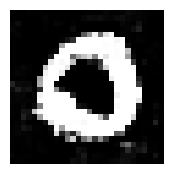

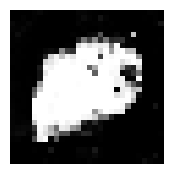

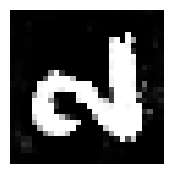

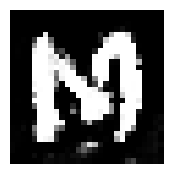

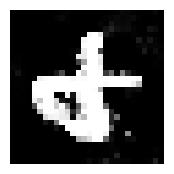

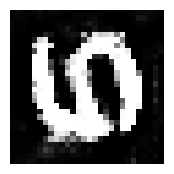

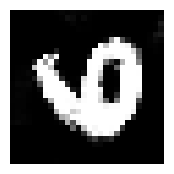

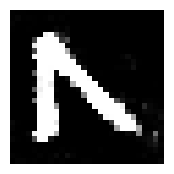

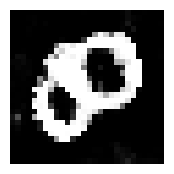

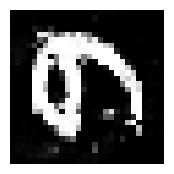

In [173]:
import os
os.makedirs("samples", exist_ok=True)

for i in range(10):
    img_up = generate_digit(i)  # generates and returns digit i
    # Correct f-string syntax
    plt.imsave(f"samples/digit_{i}.png", img_up.squeeze().cpu(), cmap='gray', format='png')

Result